In [1]:
%pip install -qU ddgs arxiv langchain-community langchain-google-community\[gmail\]

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install --upgrade langchain 

Note: you may need to restart the kernel to use updated packages.


In [3]:
from dotenv import load_dotenv 

load_dotenv()

True

In [4]:
from langchain.chat_models.base import init_chat_model

llm = init_chat_model(model="gpt-4o-mini", model_provider="openai")

In [5]:
from langchain_core.tools import tool 

# @tool: 데코레이터를 사용하여 도구 정의
# add: 도구의 이름
# description: 도구에 대한 설명
# a, b: 도구가 받을 매개변수
# return: 도구가 반환하는 값의 타입(Expected Argument)
@tool 
def add(a: int, b: int) -> int:
    """숫자 a와 b를 더합니다."""
    return a + b

@tool
def multiply(a: int, b: int) -> int:
    """숫자 a와 b를 곱합니다."""
    return a * b

In [6]:
from langchain_community.tools import DuckDuckGoSearchRun 

search_tool = DuckDuckGoSearchRun()

In [7]:
search_tool 

DuckDuckGoSearchRun(api_wrapper=DuckDuckGoSearchAPIWrapper(region='wt-wt', safesearch='moderate', time='y', max_results=5, backend='auto', source='text'))

In [8]:
from langchain_google_community import GmailToolkit

from langchain_google_community.gmail.utils import (
    build_resource_service,
    get_gmail_credentials,
)

credentials = get_gmail_credentials(
    token_file="./google/gmail_token.json",
    scopes=["https://mail.google.com/"],
    client_sercret_file="./google/gmail_credentials.json",
)
api_resource = build_resource_service(credentials=credentials)
gmail_toolkit = GmailToolkit(api_resource=api_resource)

gmail_tool_list = gmail_toolkit.get_tools()

/var/folders/z0/1s99gknj53x_1hd6ndb09frh0000gn/T/ipykernel_56738/4172087591.py:8: DeprecationWarning: get_gmail_credentials is deprecated and will be removed in a future version.Use get_google_credentials instead.
  credentials = get_gmail_credentials(
/var/folders/z0/1s99gknj53x_1hd6ndb09frh0000gn/T/ipykernel_56738/4172087591.py:13: DeprecationWarning: build_resource_service is deprecated and will be removed in a future version.Use build_gmail_service instead.
  api_resource = build_resource_service(credentials=credentials)


In [9]:
gmail_tool_list

[GmailCreateDraft(api_resource=<googleapiclient.discovery.Resource object at 0x113186bd0>),
 GmailSendMessage(api_resource=<googleapiclient.discovery.Resource object at 0x113186bd0>),
 GmailSearch(api_resource=<googleapiclient.discovery.Resource object at 0x113186bd0>),
 GmailGetMessage(api_resource=<googleapiclient.discovery.Resource object at 0x113186bd0>),
 GmailGetThread(api_resource=<googleapiclient.discovery.Resource object at 0x113186bd0>)]

In [10]:
from langgraph.prebuilt import ToolNode 

tool_list = [add, multiply, search_tool] + gmail_tool_list
llm_with_tools = llm.bind_tools(tool_list)
tool_node = ToolNode(tool_list)

In [11]:
from langgraph.graph import MessagesState, StateGraph 

graph_builder = StateGraph(MessagesState)

In [12]:
def agent(state: MessagesState):
    messages = state['messages']
    response = llm_with_tools.invoke(messages)
    return {'messages': [response]}

In [13]:
from langgraph.graph import END 

def should_continue(state: MessagesState):
    messages = state['messages']
    last_ai_message = messages[-1]
    if last_ai_message.tool_calls:
        return 'tools'
    return END

In [14]:
graph_builder.add_node('agent', agent)
graph_builder.add_node('tools', tool_node)


In [15]:
from langgraph.graph import START, END 

graph_builder.add_edge(START, 'agent')
graph_builder.add_conditional_edges(
    'agent',
    should_continue,
    ['tools', END]
)
graph_builder.add_edge('tools', 'agent')

In [16]:
graph = graph_builder.compile()

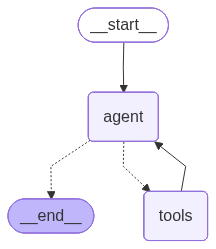

In [17]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [18]:
from langchain_core.messages import HumanMessage

query = 'What currency is in Billy Giles\' birthplace? Find currency and email it to yongbum10002@gmail.com'

for chunk in graph.stream({'messages': [HumanMessage(query)]}, stream_mode='values'):
    chunk['messages'][-1].pretty_print()



================================ Human Message =================================

What currency is in Billy Giles' birthplace? Find currency and email it to yongbum10002@gmail.com
================================== Ai Message ==================================
Tool Calls:
  duckduckgo_search (call_6MZsBdcQtWZhLHksOZkS8YL8)
 Call ID: call_6MZsBdcQtWZhLHksOZkS8YL8
  Args:
    query: Billy Giles birthplace
================================= Tool Message =================================
Name: duckduckgo_search

Billy Giles was born William Alexander Ellis Giles in Belfast, Northern Ireland on 3 September 1957, and grew up in Island Street, in loyalist east Belfast. His father Sam, worked as a plater in the nearby Harland & Wolff shipyard, and his mother, Lily was a housewife. Genealogy for William Giles (1686 - 1727) family tree on Geni, with over 275 million profiles of ancestors and living relatives. Have questions about Constellation Brands Director William Giles ? View Mr. Giles's net 